In [1]:
import numpy as np
import matplotlib.pyplot as plt

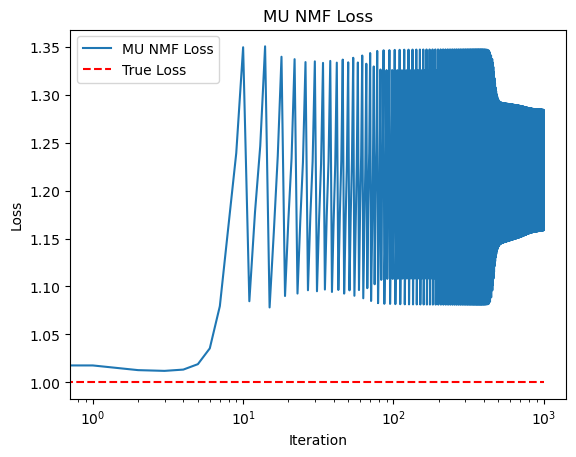

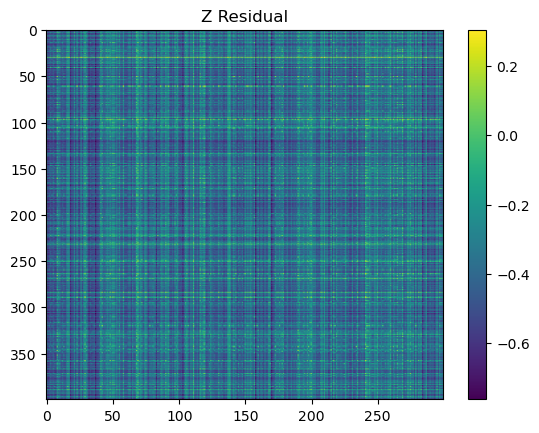

In [ ]:
m = 400
n = 300
k = 5

A = np.random.rand(m, k)
B = np.random.rand(k, n)
Z = np.exp(-A @ B)
T = Z#np.random.poisson(Z)

A_hat = np.random.rand(m, k)
B_hat = np.random.rand(k, n)

def loss(A_hat, B_hat):
    V_hat = A_hat @ B_hat
    return np.sum(np.exp(-V_hat) + T * V_hat)

losses = [loss(A_hat, B_hat)]
for i in range(1000):
    Z_hat = np.exp(-A_hat @ B_hat)
    A_hat = np.maximum(A_hat * (Z_hat @ B_hat.T) / (T @ B_hat.T), 1e-10)
    B_hat = np.maximum(B_hat * (A_hat.T @ Z_hat) / (A_hat.T @ T), 1e-10)
    losses.append(loss(A_hat, B_hat))
plt.plot(losses, label='MU NMF Loss')
plt.hlines(loss(A, B), 0, len(losses)-1, color='red', linestyle='dashed', label='True Loss')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MU NMF Loss')
plt.xscale('log')
plt.show()

plt.imshow(Z - np.exp(-A_hat @ B_hat), aspect='auto')
plt.colorbar()
plt.title('Z Residual')
plt.show()